# COPD Pathology Modeling
## Oxygen Diffusion in Deformed Pulmonary Acinus

This notebook models two effects of Chronic Obstructive Pulmonary Disease (COPD, *BPCO* in French) on oxygen transport:

1. **Tissue destruction / obstruction** — regions of the domain where oxygen can no longer diffuse. They are removed from the domain and their edges act as impermeable (no-flux) walls.
2. **Membrane thickening** — a lower membrane permeability $W$, i.e. a larger screening length $\Lambda = D / W$.

Lesions are generated randomly; a fixed seed keeps the results reproducible.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the package importable without installing it (pip install -e . also works)
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

from acinus_diffusion import (PhysicalConstants as P, calculate_oxygen_flux,
                              create_copd_domain, grid_spacing,
                              solve_quasistationary_diffusion, solve_stationary_diffusion)

print("COPD Pathology: Oxygen Diffusion in Deformed Acinus")
print("=" * 60)

COPD Pathology: Oxygen Diffusion in Deformed Acinus


## 1. Model Parameters

In [2]:
N, M = 100, 100
L = 0.01  # 1 cm domain
dx, dy = grid_spacing(N, M, L)
SEED = 0

TISSUE_DESTRUCTION_FACTOR = 0.3  # Severity of tissue destruction (0-1)
PERMEABILITY_FACTOR = 0.5        # Membrane permeability in COPD relative to normal

LAMBDA_NORMAL = P.LAMBDA_TYPICAL
LAMBDA_COPD = LAMBDA_NORMAL / PERMEABILITY_FACTOR  # Λ = D / W grows when W drops

print(f"Tissue destruction factor: {TISSUE_DESTRUCTION_FACTOR}")
print(f"Screening length: normal {LAMBDA_NORMAL} m, COPD {LAMBDA_COPD} m")

Tissue destruction factor: 0.3
Screening length: normal 0.28 m, COPD 0.56 m


## 2. Normal vs COPD Comparison

In [3]:
x = np.linspace(0, L, N)
y = np.linspace(0, L, M)
X, Y = np.meshgrid(x, y)

_, _, copd_mask = create_copd_domain(N, M, L, TISSUE_DESTRUCTION_FACTOR, seed=SEED)
destruction_percent = (1 - copd_mask.mean()) * 100

C_normal = solve_stationary_diffusion(N, M, L, lambda_param=LAMBDA_NORMAL)
C_geometry = solve_stationary_diffusion(N, M, L, lambda_param=LAMBDA_NORMAL, mask=copd_mask)
C_copd = solve_stationary_diffusion(N, M, L, lambda_param=LAMBDA_COPD, mask=copd_mask)

flux_normal = calculate_oxygen_flux(C_normal, dx, LAMBDA_NORMAL)
flux_geometry = calculate_oxygen_flux(C_geometry, dx, LAMBDA_NORMAL)
flux_copd = calculate_oxygen_flux(C_copd, dx, LAMBDA_COPD)

reduction_geometry = (1 - flux_geometry / flux_normal) * 100
flux_reduction = (1 - flux_copd / flux_normal) * 100

print(f"Tissue destruction in COPD model: {destruction_percent:.1f}%")
print(f"Normal oxygen flux:                   {flux_normal:.3e} mol/(m·s)")
print(f"COPD flux, tissue destruction only:   {flux_geometry:.3e} mol/(m·s) "
      f"({reduction_geometry:.1f}% reduction)")
print(f"COPD flux, destruction + membrane:    {flux_copd:.3e} mol/(m·s) "
      f"({flux_reduction:.1f}% reduction)")

Tissue destruction in COPD model: 4.5%
Normal oxygen flux:                   5.793e-06 mol/(m·s)
COPD flux, tissue destruction only:   5.755e-06 mol/(m·s) (0.6% reduction)
COPD flux, destruction + membrane:    2.938e-06 mol/(m·s) (49.3% reduction)


## 3. Visualization: Normal vs COPD

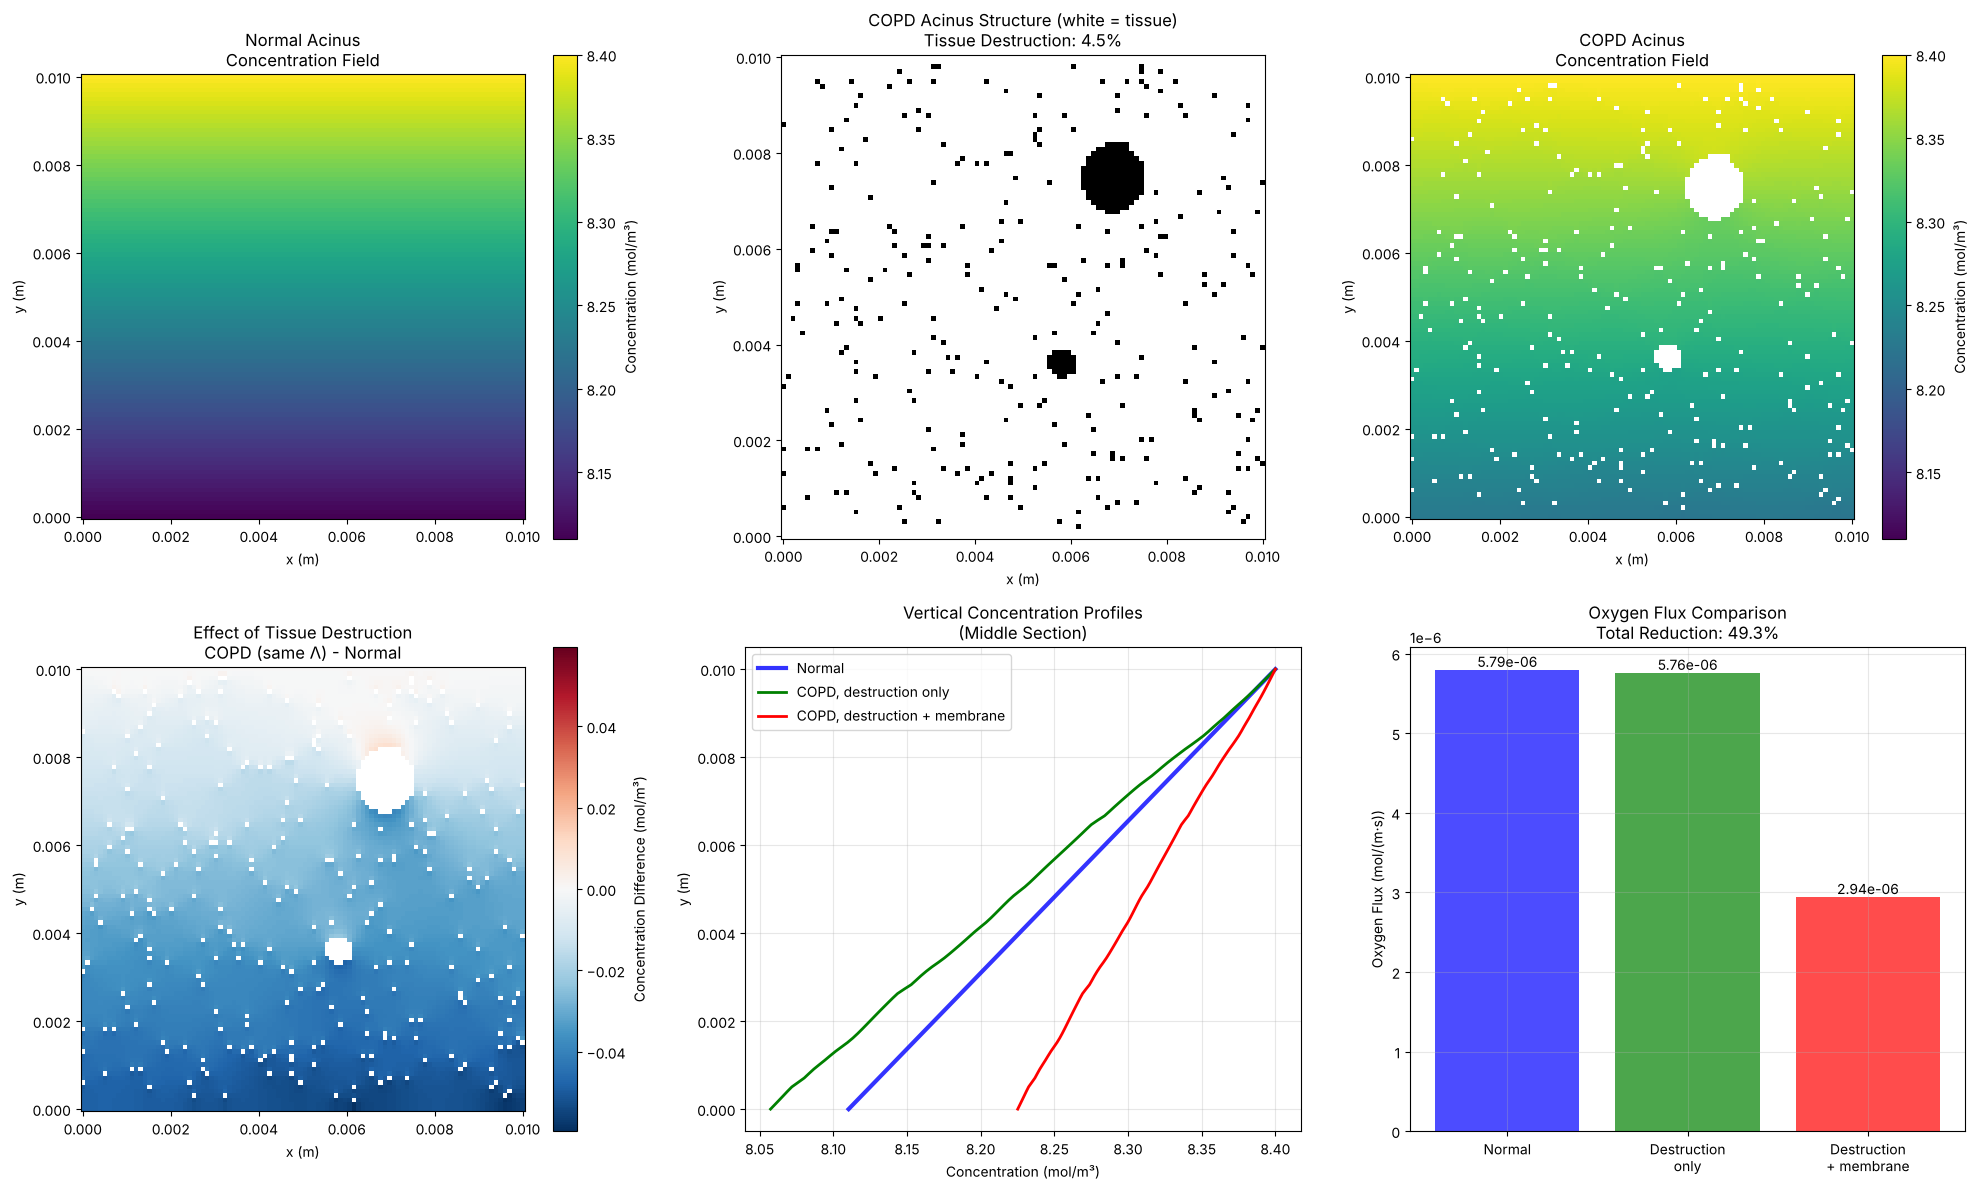

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
vmin, vmax = min(np.nanmin(C_normal), np.nanmin(C_copd)), P.C_AIR

im = axes[0, 0].pcolormesh(X, Y, C_normal, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0, 0], label='Concentration (mol/m³)')
axes[0, 0].set_title('Normal Acinus\nConcentration Field')

axes[0, 1].pcolormesh(X, Y, copd_mask, shading='auto', cmap='Greys_r')
axes[0, 1].set_title(f'COPD Acinus Structure (white = tissue)\n'
                     f'Tissue Destruction: {destruction_percent:.1f}%')

im = axes[0, 2].pcolormesh(X, Y, C_copd, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0, 2], label='Concentration (mol/m³)')
axes[0, 2].set_title('COPD Acinus\nConcentration Field')

C_diff = C_geometry - C_normal
limit = np.nanmax(np.abs(C_diff))
im = axes[1, 0].pcolormesh(X, Y, C_diff, shading='auto', cmap='RdBu_r', vmin=-limit, vmax=limit)
fig.colorbar(im, ax=axes[1, 0], label='Concentration Difference (mol/m³)')
axes[1, 0].set_title('Effect of Tissue Destruction\nCOPD (same Λ) - Normal')

for ax in (axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 0]):
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_aspect('equal')

middle_idx = N // 2
axes[1, 1].plot(C_normal[:, middle_idx], y, 'b-', linewidth=3, label='Normal', alpha=0.8)
axes[1, 1].plot(C_geometry[:, middle_idx], y, 'g-', linewidth=2, label='COPD, destruction only')
axes[1, 1].plot(C_copd[:, middle_idx], y, 'r-', linewidth=2, label='COPD, destruction + membrane')
axes[1, 1].set_xlabel('Concentration (mol/m³)')
axes[1, 1].set_ylabel('y (m)')
axes[1, 1].set_title('Vertical Concentration Profiles\n(Middle Section)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

conditions = ['Normal', 'Destruction\nonly', 'Destruction\n+ membrane']
fluxes = [flux_normal, flux_geometry, flux_copd]
bars = axes[1, 2].bar(conditions, fluxes, color=['blue', 'green', 'red'], alpha=0.7)
axes[1, 2].set_ylabel('Oxygen Flux (mol/(m·s))')
axes[1, 2].set_title(f'Oxygen Flux Comparison\nTotal Reduction: {flux_reduction:.1f}%')
axes[1, 2].grid(True, alpha=0.3)
for bar, flux in zip(bars, fluxes):
    axes[1, 2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{flux:.2e}', ha='center', va='bottom')

fig.tight_layout()
plt.show()

**Interpretation.** At the physiological screening length ($\Lambda \gg L$) the acinus works in the membrane-limited regime: the concentration is nearly uniform, so obstacles in the gas phase only slightly reduce the flux, whereas a less permeable membrane reduces it almost proportionally. Tissue destruction matters more when $\Lambda$ is comparable to or smaller than $L$ (see below).

## 4. COPD Severity Progression

Severity 0.0: destruction  0.0%, Λ=0.28 m: -0.0%, Λ=0.01 m: -0.0%, Λ=0.002 m: -0.0%


Severity 0.1: destruction  0.8%, Λ=0.28 m: -0.2%, Λ=0.01 m: -2.2%, Λ=0.002 m: -3.6%


Severity 0.2: destruction  1.9%, Λ=0.28 m: -0.3%, Λ=0.01 m: -4.6%, Λ=0.002 m: -7.4%


Severity 0.3: destruction  4.5%, Λ=0.28 m: -0.6%, Λ=0.01 m: -8.6%, Λ=0.002 m: -13.5%


Severity 0.4: destruction  6.8%, Λ=0.28 m: -0.9%, Λ=0.01 m: -11.6%, Λ=0.002 m: -17.9%


Severity 0.5: destruction  9.6%, Λ=0.28 m: -1.3%, Λ=0.01 m: -16.3%, Λ=0.002 m: -24.5%


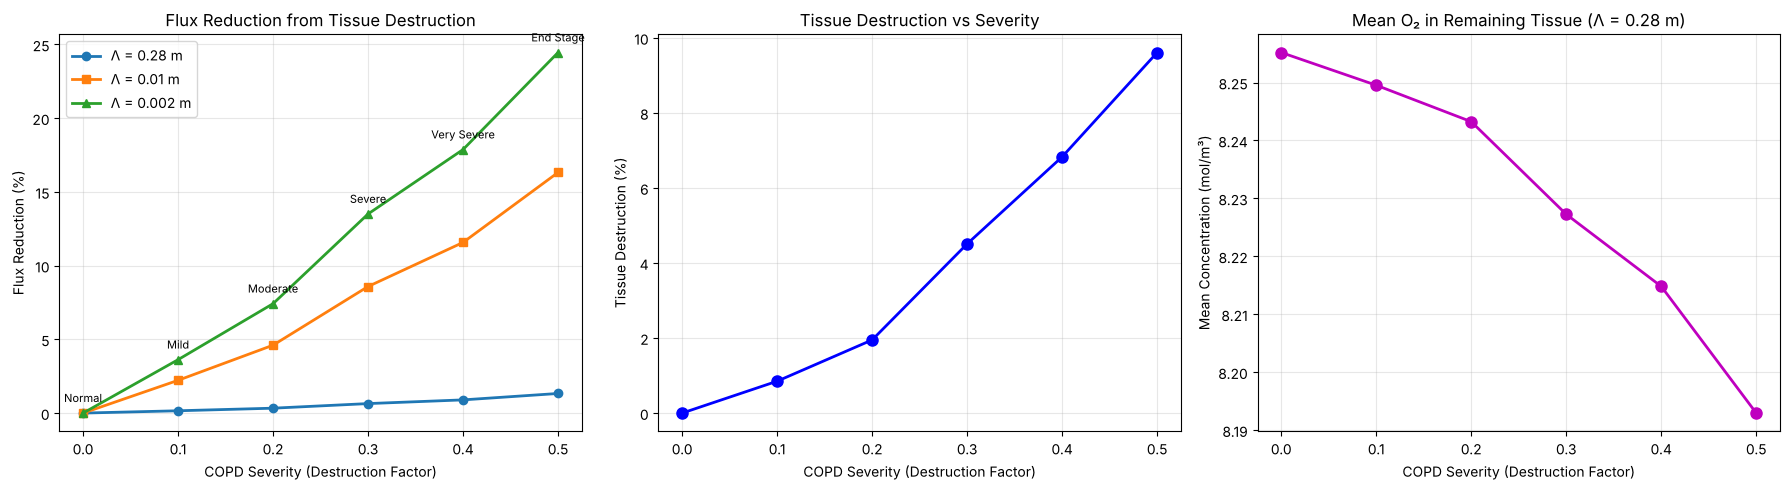

In [5]:
severity_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
severity_labels = ['Normal', 'Mild', 'Moderate', 'Severe', 'Very Severe', 'End Stage']
lambda_scan = [LAMBDA_NORMAL, 0.01, 0.002]

destruction_percentages = []
mean_concentrations = []
reductions = {lam: [] for lam in lambda_scan}

for severity in severity_levels:
    _, _, mask = create_copd_domain(N, M, L, severity, seed=SEED)
    destruction_percentages.append((1 - mask.mean()) * 100)

    for lam in lambda_scan:
        C_ref = solve_stationary_diffusion(N, M, L, lambda_param=lam)
        C = solve_stationary_diffusion(N, M, L, lambda_param=lam, mask=mask)
        reduction = 1 - calculate_oxygen_flux(C, dx, lam) / calculate_oxygen_flux(C_ref, dx, lam)
        reductions[lam].append(reduction * 100)
        if lam == LAMBDA_NORMAL:
            mean_concentrations.append(np.nanmean(C))

    print(f"Severity {severity:.1f}: destruction {destruction_percentages[-1]:4.1f}%, "
          + ", ".join(f"Λ={lam:g} m: -{reductions[lam][-1]:.1f}%" for lam in lambda_scan))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for lam, marker in zip(lambda_scan, 'os^'):
    axes[0].plot(severity_levels, reductions[lam], marker=marker, linewidth=2, label=f'Λ = {lam:g} m')
axes[0].set_xlabel('COPD Severity (Destruction Factor)')
axes[0].set_ylabel('Flux Reduction (%)')
axes[0].set_title('Flux Reduction from Tissue Destruction')
axes[0].legend()
for i, label in enumerate(severity_labels):
    axes[0].annotate(label, (severity_levels[i], reductions[lambda_scan[-1]][i]),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)

axes[1].plot(severity_levels, destruction_percentages, 'bo-', linewidth=2, markersize=8)
axes[1].set_xlabel('COPD Severity (Destruction Factor)')
axes[1].set_ylabel('Tissue Destruction (%)')
axes[1].set_title('Tissue Destruction vs Severity')

axes[2].plot(severity_levels, mean_concentrations, 'mo-', linewidth=2, markersize=8)
axes[2].set_xlabel('COPD Severity (Destruction Factor)')
axes[2].set_ylabel('Mean Concentration (mol/m³)')
axes[2].set_title(f'Mean O₂ in Remaining Tissue (Λ = {LAMBDA_NORMAL} m)')

for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Quasi-Stationary COPD Analysis

The quasi-stationary solver accepts the same tissue mask, so breathing dynamics can be computed directly in the deformed domain.

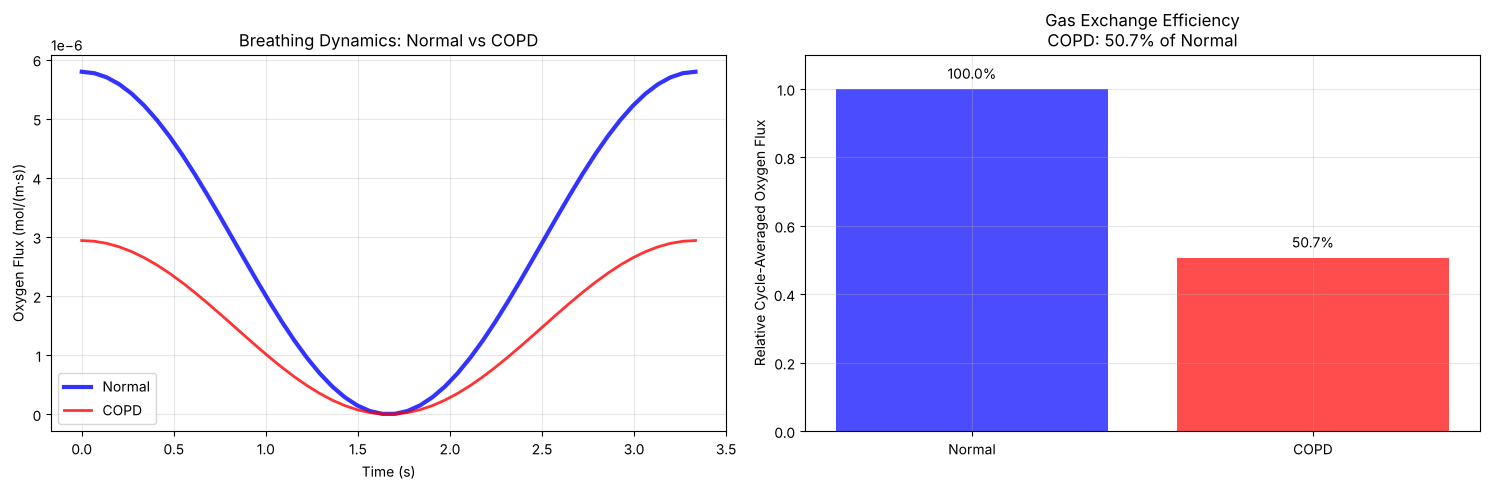

Normal average flux: 2.896e-06 mol/(m·s)
COPD average flux:   1.469e-06 mol/(m·s)
Gas exchange efficiency: 50.7%


In [6]:
period = 1 / P.BREATHING_RATE_REST
time_points = np.linspace(0, period, 50)

normal_flux_cycle = []
copd_flux_cycle = []

for t in time_points:
    C_n, _ = solve_quasistationary_diffusion(N, M, L, t, lambda_param=LAMBDA_NORMAL)
    normal_flux_cycle.append(calculate_oxygen_flux(C_n, dx, LAMBDA_NORMAL))

    C_c, _ = solve_quasistationary_diffusion(N, M, L, t, lambda_param=LAMBDA_COPD, mask=copd_mask)
    copd_flux_cycle.append(calculate_oxygen_flux(C_c, dx, LAMBDA_COPD))

normal_avg = np.mean(normal_flux_cycle[:-1])
copd_avg = np.mean(copd_flux_cycle[:-1])
efficiency_ratio = copd_avg / normal_avg

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(time_points, normal_flux_cycle, 'b-', linewidth=3, label='Normal', alpha=0.8)
axes[0].plot(time_points, copd_flux_cycle, 'r-', linewidth=2, label='COPD', alpha=0.8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Oxygen Flux (mol/(m·s))')
axes[0].set_title('Breathing Dynamics: Normal vs COPD')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(['Normal', 'COPD'], [1.0, efficiency_ratio], color=['blue', 'red'], alpha=0.7)
axes[1].set_ylabel('Relative Cycle-Averaged Oxygen Flux')
axes[1].set_title(f'Gas Exchange Efficiency\nCOPD: {efficiency_ratio:.1%} of Normal')
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3)
for bar, eff in zip(bars, [1.0, efficiency_ratio]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{eff:.1%}', ha='center', va='bottom')

fig.tight_layout()
plt.show()

print(f"Normal average flux: {normal_avg:.3e} mol/(m·s)")
print(f"COPD average flux:   {copd_avg:.3e} mol/(m·s)")
print(f"Gas exchange efficiency: {efficiency_ratio:.1%}")

## 6. Summary

In [7]:
print("=" * 60)
print("COPD PATHOLOGY MODELING SUMMARY")
print("=" * 60)
print(f"Tissue destruction factor {TISSUE_DESTRUCTION_FACTOR}: {destruction_percent:.1f}% of the domain destroyed")
print(f"Flux reduction, tissue destruction only (Λ = {LAMBDA_NORMAL} m): {reduction_geometry:.1f}%")
print(f"Flux reduction, destruction + membrane permeability x{PERMEABILITY_FACTOR}: {flux_reduction:.1f}%")
print(f"Cycle-averaged gas exchange efficiency in COPD: {efficiency_ratio:.1%} of normal")

COPD PATHOLOGY MODELING SUMMARY
Tissue destruction factor 0.3: 4.5% of the domain destroyed
Flux reduction, tissue destruction only (Λ = 0.28 m): 0.6%
Flux reduction, destruction + membrane permeability x0.5: 49.3%
Cycle-averaged gas exchange efficiency in COPD: 50.7% of normal


* At the physiological screening length the flux is controlled by the membrane, so membrane damage has a much larger effect than obstacles in the gas phase.
* The impact of tissue destruction grows as $\Lambda$ decreases (diffusion-limited regime).
* The breathing dynamics are unchanged in shape; the COPD flux is reduced by the same factor over the whole cycle.

**Limitations.** 2D geometry, randomly placed lesions rather than patient-specific anatomy, homogeneous tissue and membrane properties, and the quasi-stationary approximation. Results are qualitative and are not validated against clinical data.